# Convolutional Neural Networks for Image Classification

Goals of the lecture:
1. Get to know the UC Merced Land Use Dataset
2. Understand single-label classification (SLC)
3. Learn about image transformations in the training pipeline
4. Train a predefined ResNet18 model
5. Understand and make use of Transfer Learning

This practical lecture utilizes [UC Merced Land Use Dataset](http://weegee.vision.ucmerced.edu/datasets/landuse.html) for CNN based single-label classification.

UC Merced Land Use Dataset contains 2100 RGB aerial images with a size of
256 × 256 pixels and a spatial resolution of 0.3 m. The single-label version of the dataset consists of 21 land use classes, including: agricultural, airplane, baseballdiamond, beach, buildings, chaparral, denseresidential, forest, freeway, golfcourse, harbor, intersection, mediumresidential, mobilehomepark, overpass, parkinglot, river, runway, sparseresidential, storagetanks, tenniscourt.

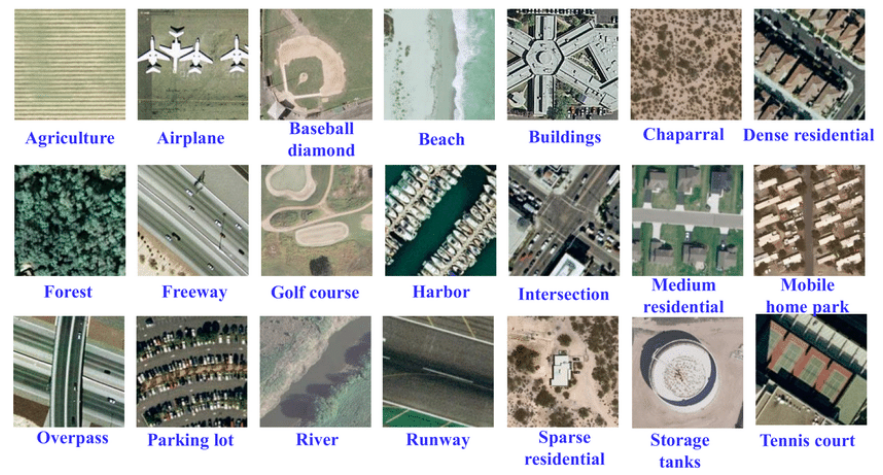

## Import Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import requests
from tqdm.notebook import tqdm
from pathlib import Path


def download_file_with_progress(url: str, output_file: Path):
    """
    Given a `url` as a String and an `output_file` as a file-path the item will
    be downloaded and written to the `output_file`. If the `output_file` already
    exists, it will be overwritten.
    """
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get("content-length", 0))
    chunk_size = 2**20  # mb

    with open(output_file, "wb") as f:
        for data in tqdm(
            response.iter_content(chunk_size=chunk_size),
            total=total_size // chunk_size,
            unit="MB",
            unit_scale=True,
            desc="Downloading",
        ):
            f.write(data)

In [3]:
data_path = Path("./data")
data_path.mkdir(exist_ok=True)
# For quick prototyping there is on such things as _too many_ asserts!
assert data_path.exists, "Should exist after calling mkdir!"

## Define Dataset in PyTorch and Download Data

In [4]:
import zipfile
from PIL import Image
from torchvision import transforms # Image transformations.
from torch.utils.data import Dataset

# Class to handle the data. Using Dataset class to be compatible with pytorch. Extends Dataset class.
class UCMerced(Dataset):
    def __init__(self, base_dir: Path, img_transform: transforms = None):
        self.base_dir = base_dir
        self.download_dataset()
        self.images_path = base_dir / "UCMerced_LandUse/Images"
        self.class_names = sorted(
            [cl.name for cl in self.images_path.iterdir() if not cl.name.startswith(".")] # Excluding .FOLDER that may be created by MacOS. 
        )
        self.img_paths, self.targets = self.read_data()
        self.img_transform = img_transform
            
    def download_dataset(self):
        ucmerced_path = self.base_dir / "UCMerced.zip"
        if not ucmerced_path.exists():
            print("Downloading UCMerced")
            download_file_with_progress(
                "https://tubcloud.tu-berlin.de/s/GmzQrDMqC2t7EYq/download",
                ucmerced_path,
            )
            zipf = zipfile.ZipFile(ucmerced_path)
            zipf.extractall(self.base_dir)

    def read_data(self):
        img_paths, targets = [], []
        for cl_id, cl_name in enumerate(self.class_names):
            cl_path = self.images_path / cl_name

            for img_path in sorted(cl_path.iterdir()):
                img_paths.append(img_path)
                targets.append(cl_id)
                
        return img_paths, targets

    # Return the nth item from the dataset.
    def __getitem__(self, idx: int):
        img_path = self.img_paths[idx]
        target = self.targets[idx]

        img = Image.open(img_path).convert("RGB") # Making sure the image is only RGB.
        if self.img_transform is not None:
            img = self.img_transform(img)

        return img, target

    def __len__(self):
        return len(self.img_paths)

In [5]:
full_dataset = UCMerced(data_path)

Downloading:   0%|          | 0.00/316 [00:00<?, ?MB/s]

In [9]:
full_dataset[200]

(<PIL.Image.Image image mode=RGB size=256x256>, 2)

In [13]:
full_dataset.class_names[full_dataset[200][1]] # Class label.

'baseballdiamond'

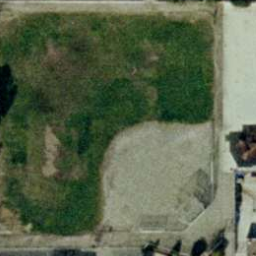

In [15]:
full_dataset[200][0] # Image.

In [16]:
print("\n".join(full_dataset.class_names))

agricultural
airplane
baseballdiamond
beach
buildings
chaparral
denseresidential
forest
freeway
golfcourse
harbor
intersection
mediumresidential
mobilehomepark
overpass
parkinglot
river
runway
sparseresidential
storagetanks
tenniscourt


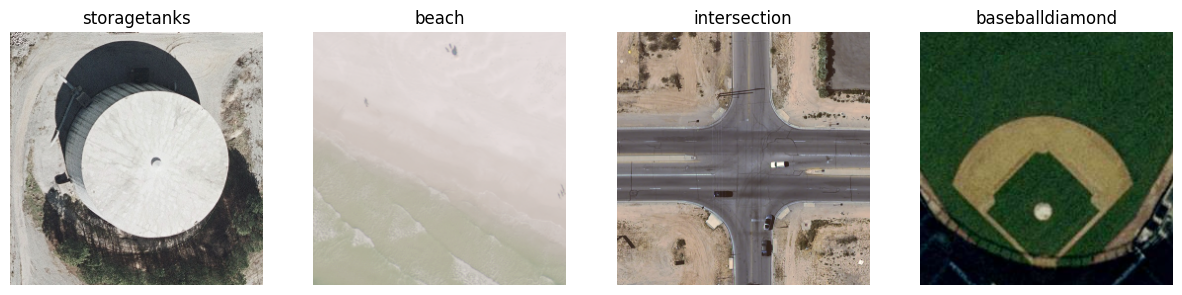

In [17]:
# Plot random images with class labels.
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes = axes.flatten()

for i in range(4):
    idx = np.random.randint(low=0, high=2100)
    img, label = full_dataset[idx]
    axes[i].imshow(img)
    axes[i].set_title(full_dataset.class_names[label])
    axes[i].axis('off')

## Define Customized PyTorch Model

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CNN2D(nn.Module):
    def __init__(self, num_channels: int, input_shape: tuple, num_classes: int, num_filter: int = 2):
        super(CNN2D, self).__init__()
        self.num_channels = num_channels
        self.num_filter = num_filter
        self.input_shape = input_shape

        self.conv1 = nn.Conv2d(num_channels, num_filter, kernel_size=(7, 7), stride=2, padding=3)
        self.pool1 = nn.MaxPool2d((2, 2))
        
        self.conv2 = nn.Conv2d(num_filter, 2 * num_filter, kernel_size=(3, 3), padding=1)
        self.pool2 = nn.MaxPool2d((2, 2))
        
        self.features_size = self._get_final_flattened_size()

        self.fc = nn.Linear(self.features_size, num_classes)

    # Overwrite the forward function of NN module.
    # This function is essential to use the model.
    def forward(self, x: torch.Tensor):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.reshape(-1, self.features_size)
        x = self.fc(x)
        return x

    def _get_final_flattened_size(self):
        with torch.no_grad():
            x = torch.zeros((1, self.num_channels, self.input_shape[0], self.input_shape[1]))
            x = F.relu(self.conv1(x))
            x = self.pool1(x)
            x = F.relu(self.conv2(x))
            x = self.pool2(x)
            b, c, w, h = x.size()
        return b * c * w * h # b batachsize, c channel number, w weight, h number classes???

In [20]:
cnn2d = CNN2D(num_channels=3, input_shape=(64, 64), num_classes=21, num_filter=10) # num_channels = 3 because RGB. num_classes = 21 b/c we need output size 21 to accommodate all classes.

In [21]:
from torchinfo import summary

summary(cnn2d, input_size=(3, 64, 64), col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
CNN2D                                    [3, 64, 64]               [1, 21]                   --
├─Conv2d: 1-1                            [3, 64, 64]               [10, 32, 32]              1,480
├─MaxPool2d: 1-2                         [10, 32, 32]              [10, 16, 16]              --
├─Conv2d: 1-3                            [10, 16, 16]              [20, 16, 16]              1,820
├─MaxPool2d: 1-4                         [20, 16, 16]              [20, 8, 8]                --
├─Linear: 1-5                            [1, 1280]                 [1, 21]                   26,901
Total params: 30,201
Trainable params: 30,201
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.08
Input size (MB): 0.05
Forward/backward pass size (MB): 0.12
Params size (MB): 0.12
Estimated Total Size (MB): 0.29

Convolutional Layer Output size: $\frac{N-F + 2P}{S}+1$ 

* Padding P
* F filter size / kernel size
* N input size
* S stride
* But result is also floored.

Pooling Layer Output size: $\frac{N - F}{S} + 1$

* Stride = Size of filter if not specified.

# Define Training Hyperparameter

In [22]:
def get_device(cuda_no):
    return torch.device('cpu') if cuda_no < 0 or not torch.cuda.is_available() else torch.device(cuda_no)

In [25]:
device         = get_device(0)
batch_size     = 64 # How many images per time.
learning_rate  = 0.01
epochs         = 10 # How many time to pass all the data.

In [71]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # Loss function for single label classification.
optimizer = optim.SGD(
    cnn2d.parameters(), # The paramaters to optomize.
    lr=learning_rate,
    momentum=0.9,
    weight_decay=0.00005,
    nesterov=True,
)

# Transformations

Transformations are usually applied to the images as part of the data loading process to improve the training process. They usually include:
- transforming numpy arrays or PIL images to PyTorch tensors
- normalizing the data per channel by mean 0 and standard deviation of 1
- data augmentation techniques

Why transformations
* Increase dataset
* Avoid overfitting

In [30]:
?transforms.ToTensor

Init signature: transforms.ToTensor() -> None
Docstring:     
Convert a PIL Image or ndarray to tensor and scale the values accordingly.

This transform does not support torchscript.

Converts a PIL Image or numpy.ndarray (H x W x C) in the range
[0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]
if the PIL Image belongs to one of the modes (L, LA, P, I, F, RGB, YCbCr, RGBA, CMYK, 1)
or if the numpy.ndarray has dtype = np.uint8

In the other cases, tensors are returned without scaling.

.. note::
    Because the input image is scaled to [0.0, 1.0], this transformation should not be used when
    transforming target image masks. See the `references`_ for implementing the transforms for image masks.

.. _references: https://github.com/pytorch/vision/tree/main/references/segmentation
File:           c:\users\max\documents\github\ipl4eo-dependencies\.venv\lib\site-packages\torchvision\transforms\transforms.py
Type:           type
Subclasses:     

In [31]:
# Normalize the images. To improve learning process.
?transforms.Normalize

Init signature: transforms.Normalize(mean, std, inplace=False)
Docstring:     
Normalize a tensor image with mean and standard deviation.
This transform does not support PIL Image.
Given mean: ``(mean[1],...,mean[n])`` and std: ``(std[1],..,std[n])`` for ``n``
channels, this transform will normalize each channel of the input
``torch.*Tensor`` i.e.,
``output[channel] = (input[channel] - mean[channel]) / std[channel]``

.. note::
    This transform acts out of place, i.e., it does not mutate the input tensor.

Args:
    mean (sequence): Sequence of means for each channel.
    std (sequence): Sequence of standard deviations for each channel.
    inplace(bool,optional): Bool to make this operation in-place.
Init docstring: Initialize internal Module state, shared by both nn.Module and ScriptModule.
File:           c:\users\max\documents\github\ipl4eo-dependencies\.venv\lib\site-packages\torchvision\transforms\transforms.py
Type:           type
Subclasses:     

In [32]:
# mean+std precomputed on whole dataset
ucm_mean = [0.595425, 0.3518577, 0.3225522]  
ucm_std = [0.19303136, 0.12492529, 0.10577361]

# Different transform functions during testing and training. Only during the training transformations are desired.
tr_transform = transforms.Compose(
    [
        transforms.Resize((64, 64)), # To be more compute efficient.
        transforms.ToTensor(),
        transforms.Normalize(mean=ucm_mean, std=ucm_std),
    ]
)

te_transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=ucm_mean, std=ucm_std),
    ]
)

### Example of ColorJitter Data Augmentation

<img src="https://pytorch.org/vision/stable/_images/sphx_glr_plot_transforms_illustrations_012.png" align="center" alt="Drawing" style="width: 900px;height:200px"/>

Source: https://pytorch.org/vision/stable/_images/sphx_glr_plot_transforms_illustrations_012.png

### Example of RandomResizeCrop Data Augmentation

<img src="https://pytorch.org/vision/stable/_images/sphx_glr_plot_transforms_illustrations_010.png" align="center" alt="Drawing" style="width: 900px;height:200px"/>

Source: https://pytorch.org/vision/stable/_images/sphx_glr_plot_transforms_illustrations_010.png

# Create Split and Set-Up DataLoader

In [33]:
from sklearn.model_selection import train_test_split # Have unseen data for the testing.

In [34]:
?train_test_split

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

In [37]:
def get_split_idx(targets: np.array, train_size: float, val_size: float, test_size: float):
    assert train_size + val_size + test_size == 1
    relative_val_size = val_size / (1 - test_size)
    full_idx = np.arange(0, len(targets))
    train_val_idx, test_idx, y_trainval, y_test = train_test_split(
        full_idx, targets, test_size=test_size, stratify=targets
    )
    train_idx, val_idx, y_train, y_val = train_test_split(
        train_val_idx, y_trainval, test_size=relative_val_size, stratify=y_trainval
    )
    return train_idx, val_idx, test_idx

In [38]:
# compute train, val & test set idx
train_size = 0.5
val_size   = 0.2 # On the validation data the NN can be trained.
test_size  = 0.3 # Not allowed to train at all on the test data.
train_idx, val_idx, test_idx = get_split_idx(full_dataset.targets, train_size, val_size, test_size)

In [39]:
print(f"train_len: {len(train_idx):>4} ({len(train_idx)/len(full_dataset.targets)*100:.2f}%)")
print(f"  val_len: {len(val_idx):>4} ({len(val_idx)/len(full_dataset.targets)*100:.2f}%)")
print(f" test_len: {len(test_idx):>4} ({len(test_idx)/len(full_dataset.targets)*100:.2f}%)")

train_len: 1049 (49.95%)
  val_len:  421 (20.05%)
 test_len:  630 (30.00%)


In [40]:
# instatiate one full dataset with train transformation and one with test transformation
full_dataset_tr = UCMerced(data_path, img_transform=tr_transform)
full_dataset_te = UCMerced(data_path, img_transform=te_transform)

## Image Transformations

In [64]:
# Image transformations
example_transform_normal = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        # transforms.Normalize(mean=ucm_mean, std=ucm_std),
    ]
)

example_dataset_normal = UCMerced(data_path, img_transform=example_transform_normal)

example_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(size=64),
        transforms.RandomGrayscale(p=0.2),
        #transforms.GaussianBlur(size=2),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        #transforms.Normalize(mean=ucm_mean, std=ucm_std),
    ]
)

example_dataset = UCMerced(data_path, img_transform=example_transform)


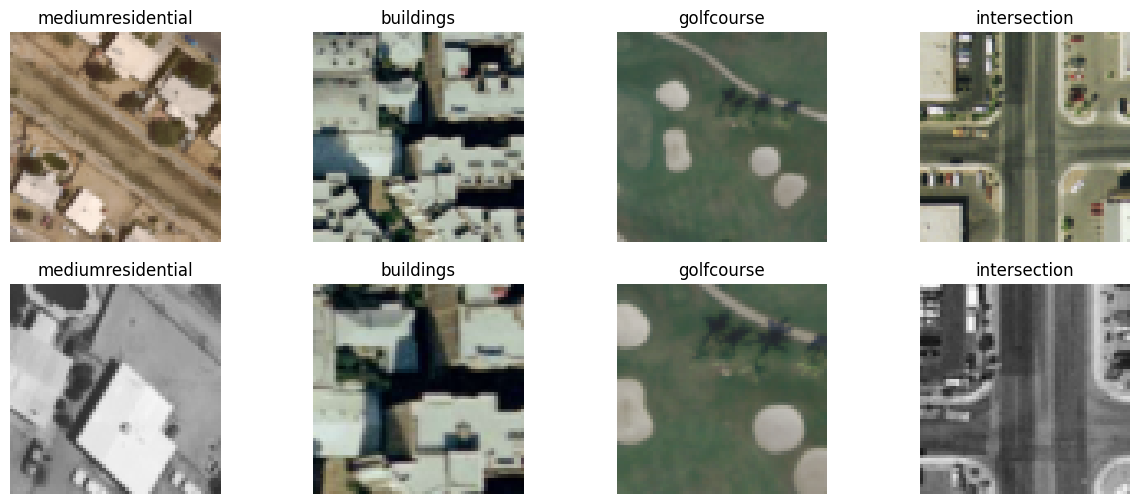

In [65]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))

for i in range(4):
    idx = np.random.randint(low=0, high=2100)
    img, label = example_dataset[idx]
    img = img.permute(1,2,0)
    
    img_normal, label_normal = example_dataset_normal[idx]
    img_normal = img_normal.permute(1,2,0)
    
    axes[0][i].imshow(img_normal)
    axes[0][i].set_title(full_dataset.class_names[label_normal])
    axes[0][i].axis('off')

    axes[1][i].imshow(img)
    axes[1][i].set_title(full_dataset.class_names[label])
    axes[1][i].axis('off')

In [66]:
from torch.utils.data import Subset, DataLoader

train_dataset = Subset(full_dataset_tr, train_idx) # Subset of the data only a the indecies.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # Returns always the batchsize

val_dataset = Subset(full_dataset_te, val_idx)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

test_dataset = Subset(full_dataset_te, test_idx)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [67]:
?Subset

Init signature:
Subset(
    dataset: torch.utils.data.dataset.Dataset[+_T_co],
    indices: Sequence[int],
) -> None
Docstring:     
Subset of a dataset at specified indices.

Args:
    dataset (Dataset): The whole Dataset
    indices (sequence): Indices in the whole set selected for subset
File:           c:\users\max\documents\github\ipl4eo-dependencies\.venv\lib\site-packages\torch\utils\data\dataset.py
Type:           type
Subclasses:     

# Train the CNN

In [68]:
import copy
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [69]:
def train(
    model: nn.Module,
    optimizer: torch.optim,
    criterion: torch.nn.modules.loss,
    train_loader: DataLoader,
    epochs: int,
    device: torch.device,
    val_loader: DataLoader = None,
):
    """
    Training loop to optimize a network for several epochs and a specified loss.

    Args:
    -----
    model               : a PyTorch model
    optimizer           : a PyTorch optimizer
    criterion           : a PyTorch-compatible loss function, e.g. nn.CrossEntropyLoss
    train_loader        : a PyTorch trainset loader
    epochs              : int specifying the number of training epochs
    device              : torch device to use (defaults to CPU)
    val_loader (opt.)   : validation dataset
    """
    model.to(device)  # put model on device
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    best_model = copy.deepcopy(model)
    best_acc = 0
    best_epoch = 1

    for epoch in tqdm(range(1, epochs + 1), desc="Training the network"):
        model.train()  # set model to training mode
        train_losses_epoch = []
        train_targets = []
        train_preds = []

        # Data-Loading Loop
        with tqdm(train_loader, unit=" batch") as tepoch:
            for idx, (data, targets) in enumerate(tepoch):
                tepoch.set_description("Epoch {}".format(epoch))

                # put loaded data and targets on device
                data, targets = data.to(device), targets.to(device)

                # zero accumulated gradients from previous batch
                optimizer.zero_grad()

                # infer predictions for batch
                output = model(data)
                predictions = output.argmax(dim=1)

                # compute loss from predictions, CELoss automatically applies F.log_softmax
                loss = criterion(output, targets)

                # accumulate gradients for all parameter according to batch errors
                loss.backward()

                # update paramters according to accumulated gradients
                optimizer.step()

                train_losses_epoch.append(loss.item())
                train_targets.append(targets)
                train_preds.append(predictions)
            
            curr_train_loss = np.mean(train_losses_epoch)
            train_targets = torch.cat(train_targets)
            train_preds = torch.cat(train_preds)

            train_accuracy = accuracy_score(train_targets, train_preds)
            train_losses.append(curr_train_loss)
            train_accuracies.append(train_accuracy)
            
            print("Train-Loss: {:.2f}. Train-Acc: {:.2f}".format(curr_train_loss, train_accuracy))

        if val_loader is not None:
            model.eval()
            val_losses_epoch = []
            val_targets = []
            val_preds = []

            with torch.no_grad():
                for data, targets in val_loader:
                    # put loaded data and targets on device
                    data = data.to(device)
                    targets = targets.to(device)

                    output = model(data)
                    loss = criterion(output, targets)
                    predictions = output.argmax(dim=1)

                    val_losses_epoch.append(loss.item())
                    val_targets.append(targets)
                    val_preds.append(predictions)
            
            curr_val_loss = np.mean(val_losses_epoch)
            val_targets = torch.cat(val_targets)
            val_preds = torch.cat(val_preds)

            val_accuracy = accuracy_score(val_targets, val_preds)
            val_losses.append(curr_val_loss)
            val_accuracies.append(val_accuracy)
            
            # early stopping: stop if 10 epochs no improvement based on validation data.
            if best_acc < val_accuracy:
                best_acc = val_accuracy
                best_epoch = epoch
                best_model = copy.deepcopy(model)

            if epoch - best_epoch > 10:
                print(f"Early stopping after {epoch} epochs with best epoch in {best_epoch}")
                break
            
            print("Val-Loss:   {:.2f}. Val-Acc:   {:.2f}".format(curr_val_loss, val_accuracy))
    
    return best_model, train_losses, val_losses, train_accuracies, val_accuracies

In [70]:
best_model, train_losses, val_losses, train_accuracies, val_accuracies = train(
    model=cnn2d,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    epochs=100,  
    device=device,
    val_loader=val_loader,
)

Training the network:   0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ? batch/s]

Train-Loss: 3.03. Train-Acc: 0.06
Val-Loss:   2.93. Val-Acc:   0.08


  0%|          | 0/17 [00:00<?, ? batch/s]

Train-Loss: 2.79. Train-Acc: 0.13
Val-Loss:   3.67. Val-Acc:   0.13


...

Train-Loss: 0.01. Train-Acc: 1.00
Val-Loss:   4.11. Val-Acc:   0.48


  0%|          | 0/17 [00:00<?, ? batch/s]

Train-Loss: 0.01. Train-Acc: 1.00
Val-Loss:   4.17. Val-Acc:   0.49


  0%|          | 0/17 [00:00<?, ? batch/s]

Train-Loss: 0.01. Train-Acc: 1.00
Early stopping after 24 epochs with best epoch in 13


# Test the CNN

In [72]:
from typing import List

def test(
    model: nn.Module,
    test_loader: DataLoader,
    class_names: List[str],
    device: torch.device,
):
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for idx, (data, target) in enumerate(tqdm(test_loader, desc="Test: ")):
            # put loaded data and targets on device
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            predicted = output.argmax(dim=1)

            predictions += predicted.tolist()
            targets += target.tolist()

    results = {}

    if class_names is None:
        class_names = range(len(np.unique(targets)))

    cm = confusion_matrix(targets, predictions)

    results["cm"] = cm
    results["overall_acc"] = accuracy_score(targets, predictions)
    results["report"] = classification_report(
        targets,
        predictions,
        target_names=class_names,
        zero_division=0,
        digits=2,
    )

    return results

In [73]:
import pandas as pd
import seaborn as sns

In [74]:
results = test(best_model, test_loader, full_dataset_tr.class_names, device)

Test:   0%|          | 0/10 [00:00<?, ?it/s]

In [75]:
print(results["report"])

                   precision    recall  f1-score   support

     agricultural       0.90      0.90      0.90        30
         airplane       0.59      0.57      0.58        30
  baseballdiamond       0.64      0.47      0.54        30
            beach       0.68      0.93      0.79        30
        buildings       0.28      0.27      0.27        30
        chaparral       0.95      0.70      0.81        30
 denseresidential       0.24      0.40      0.30        30
           forest       0.82      0.77      0.79        30
          freeway       0.36      0.53      0.43        30
       golfcourse       0.45      0.47      0.46        30
           harbor       0.58      0.60      0.59        30
     intersection       0.69      0.30      0.42        30
mediumresidential       0.16      0.17      0.16        30
   mobilehomepark       0.42      0.50      0.45        30
         overpass       0.44      0.27      0.33        30
       parkinglot       0.36      0.47      0.41       

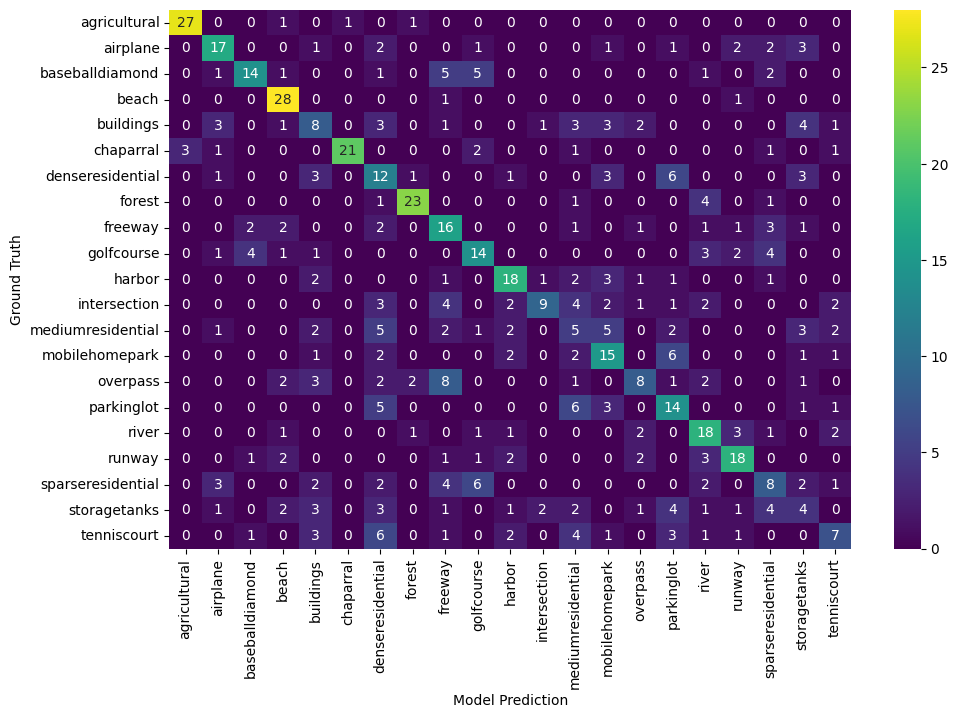

In [76]:
plt.subplots(1, 1, figsize=(11, 7))
ax = sns.heatmap(
    results["cm"],
    cmap="viridis",
    fmt="g",
    xticklabels=full_dataset_tr.class_names,
    yticklabels=full_dataset_tr.class_names,
    annot=True
)
ax.set(xlabel="Model Prediction", ylabel="Ground Truth")
plt.show()

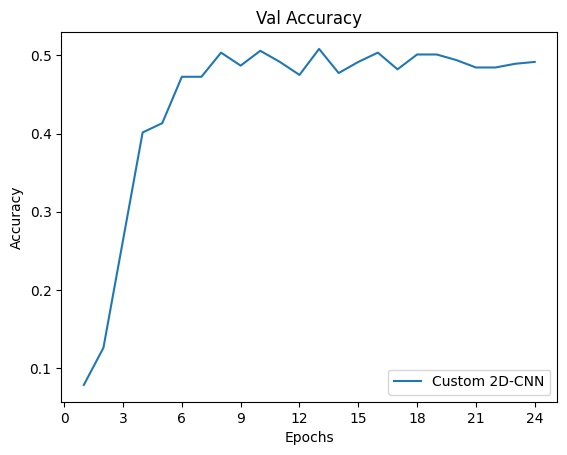

In [78]:
from matplotlib.ticker import MaxNLocator

# Plot training accuracy.

fig, ax = plt.subplots(1, 1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title('Val Accuracy')
ax.plot(np.arange(1, len(val_accuracies) + 1), val_accuracies, label="Custom 2D-CNN")
ax.set_xlabel("Epochs")
ax.set_ylabel("Accuracy")
ax.legend()

## In-course practice I

In Pytorch, you can use predefined networks (both as pre-trained or training from scratch). 

In this practice, try to use predefined `resnet18` model from Pytorch's `torchvision` library. Train it from scratch with the train set and evaluate the new model.

**Hint**: import a `resnet18` from `torchvision.models` and then train it. 

for more information check the pytorch documentation:

https://pytorch.org/docs/stable/torchvision/models.html

In [82]:
from torchvision import models

In [86]:
?models.resnet.resnet101

Signature:
models.resnet.resnet101(
    *,
    weights: Optional[torchvision.models.resnet.ResNet101_Weights] = None,
    progress: bool = True,
    **kwargs: Any,
) -> torchvision.models.resnet.ResNet
Docstring:
ResNet-101 from `Deep Residual Learning for Image Recognition <https://arxiv.org/abs/1512.03385>`__.

.. note::
   The bottleneck of TorchVision places the stride for downsampling to the second 3x3
   convolution while the original paper places it to the first 1x1 convolution.
   This variant improves the accuracy and is known as `ResNet V1.5
   <https://ngc.nvidia.com/catalog/model-scripts/nvidia:resnet_50_v1_5_for_pytorch>`_.

Args:
    weights (:class:`~torchvision.models.ResNet101_Weights`, optional): The
        pretrained weights to use. See
        :class:`~torchvision.models.ResNet101_Weights` below for
        more details, and possible values. By default, no pre-trained
        weights are used.
    progress (bool, optional): If True, displays a progress bar of the
 

In [94]:
# import ...

from torchvision import models

resnet_notpretrained = models.resnet.resnet18(weights=None, num_classes=21)
#optimizer = ...

optimizer = optim.SGD(
    resnet_notpretrained.parameters(), # The paramaters to optomize.
    lr=learning_rate,
    momentum=0.9,
    weight_decay=0.00005,
    nesterov=True,
)

In [96]:
summary(resnet_notpretrainied)

NameError: name 'resnet_notpretrainied' is not defined

In [95]:
best_model2, train_losses2, val_losses2, train_accuracies2, val_accuracies2 = train(
    model=resnet_notpretrained,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    epochs=100,
    device=device,
    val_loader=val_loader,
)

Training the network:   0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ? batch/s]

Train-Loss: 2.83. Train-Acc: 0.16
Val-Loss:   3.58. Val-Acc:   0.12


  0%|          | 0/17 [00:00<?, ? batch/s]

Train-Loss: 2.00. Train-Acc: 0.39
Val-Loss:   2.20. Val-Acc:   0.31


...

Train-Loss: 0.00. Train-Acc: 1.00
Val-Loss:   1.27. Val-Acc:   0.63


  0%|          | 0/17 [00:00<?, ? batch/s]

Train-Loss: 0.00. Train-Acc: 1.00
Val-Loss:   1.27. Val-Acc:   0.63


  0%|          | 0/17 [00:00<?, ? batch/s]

Train-Loss: 0.00. Train-Acc: 1.00
Early stopping after 27 epochs with best epoch in 16


In [97]:
results2 = test(best_model2, test_loader, full_dataset_tr.class_names, device)

Test:   0%|          | 0/10 [00:00<?, ?it/s]

In [98]:
print(results2["report"])

                   precision    recall  f1-score   support

     agricultural       0.82      0.93      0.88        30
         airplane       0.79      0.63      0.70        30
  baseballdiamond       0.42      0.47      0.44        30
            beach       0.82      0.93      0.88        30
        buildings       0.64      0.47      0.54        30
        chaparral       0.76      0.87      0.81        30
 denseresidential       0.40      0.40      0.40        30
           forest       0.72      0.93      0.81        30
          freeway       0.64      0.53      0.58        30
       golfcourse       0.42      0.33      0.37        30
           harbor       0.92      0.80      0.86        30
     intersection       0.43      0.30      0.35        30
mediumresidential       0.25      0.30      0.27        30
   mobilehomepark       0.56      0.77      0.65        30
         overpass       0.56      0.33      0.42        30
       parkinglot       0.61      0.57      0.59       

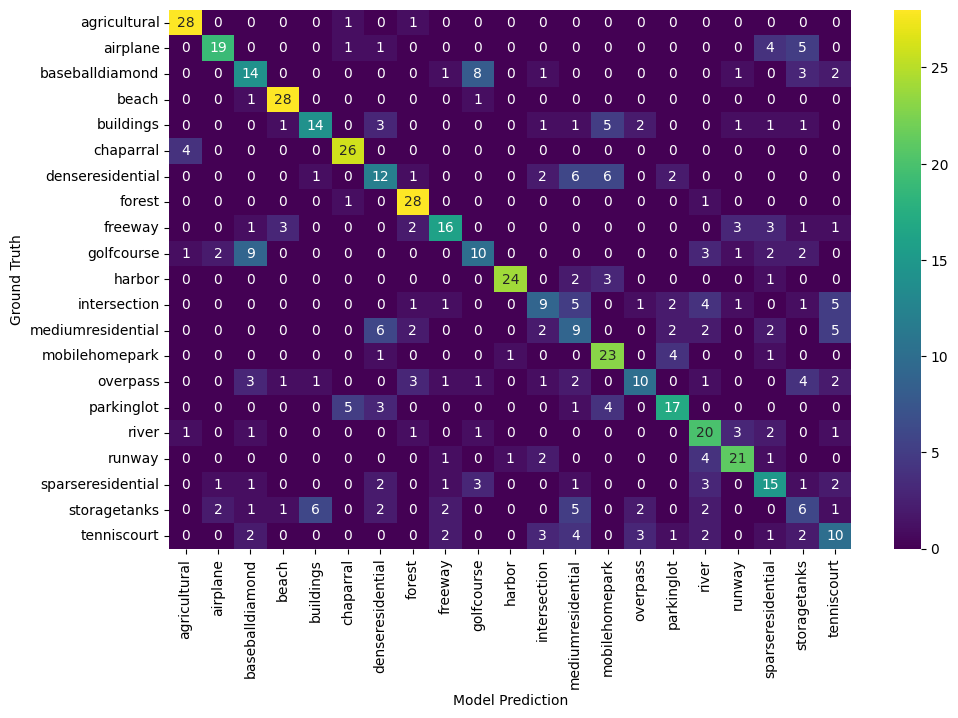

In [99]:
plt.subplots(1, 1, figsize=(11, 7))
ax = sns.heatmap(
    results2["cm"],
    cmap="viridis",
    fmt="g",
    xticklabels=full_dataset_tr.class_names,
    yticklabels=full_dataset_tr.class_names,
    annot=True
)
ax.set(xlabel="Model Prediction", ylabel="Ground Truth")
plt.show()

## In-course practice II

When using models that are pretrained on a different, usually bigger dataset (e.g. on the popular Computer Vision dataset ImageNet [1]) for a so-called downstream task in which the pretrained model is fine-tuned on the target dataset, we speak about Transfer Learning.

In this practice, try to use a pretrained version of the predefined `resnet18` model from Pytorch `models` library. You can achieve this by providing pretrained model weights to the weights parameter at initialization of the model. Use the following weights from the `torchvision` library: `torchvision.models.ResNet18_Weights.DEFAULT`. Finetune it on the train set of UCMerced dataset and evaluate the new model.

**Hint**: ImageNet consists of 1000 classes, therefore the last layer of the pretrained model needs to be alternated.

for more information check the pytorch documentation:

https://pytorch.org/docs/stable/torchvision/models.html

[1] https://www.image-net.org/index.php

In [ ]:
# import ...

resnet_pretrained = 
resnet_pretrained.fc = ...

from torchvision import models
from models import ResNet18_Weights

resnet_pretrained = models.resnet.resnet18(weights=ResNet18_Weights, num_classes=1000) # Must have output size 1000 b/c 
resnet_pretrained.fc = nn.Linear(512, 21) # Final fully connected layer replaced to fit our 21 classes.

optimizer = optim.SGD(
    resnet_pretrained.parameters(), # The paramaters to optomize.
    lr=learning_rate,
    momentum=0.9,
    weight_decay=0.00005,
    nesterov=True,
)

In [ ]:
best_model3, train_losses3, val_losses3, train_accuracies3, val_accuracies3 = train(
    model=resnet_pretrained,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    epochs=epochs,
    device=device,
    val_loader=val_loader,
)

In [ ]:
results3 = test(best_model3, test_loader, full_dataset_tr.class_names, device)

In [ ]:
print(results3["report"])

In [ ]:
plt.subplots(1, 1, figsize=(11, 7))
ax = sns.heatmap(
    results3["cm"],
    cmap="viridis",
    fmt="g",
    xticklabels=full_dataset_tr.class_names,
    yticklabels=full_dataset_tr.class_names,
    annot=True
)
ax.set(xlabel="Model Prediction", ylabel="Ground Truth")
plt.show()

## In-course practice III

Compare the validation accuracy curves of the customized 2D-CNN, the ResNet18 trained from scratch and the pretrained Resnet18.

In [ ]:
...